# QCPINN: Complex wave operator
Luego de tener los modulos corriendo y la carpeta lista para comenzar a realizar pruebas, vamos a exportar elementos de lo que tenemos que son de mayor interés para nosotros.

## 0. Importamos librerias y modulos
Llamamos a los modulos, librerias y componentes necesarios para estudio

In [1]:
# Librerias de interés
import torch
import os
import sys

import pennylane as qml

import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Global path
global_path = os.getcwd()

# Composición del path
global_path = global_path.split('/')

# Generación de path global al directorio padre 
relative_path = '/'.join(global_path[:-2])

# Linea adicional para ubicación de path en los scripts
sys.path.append(relative_path)

print(f"Se adiciona al $PATH la variable: {relative_path}")

Se adiciona al $PATH la variable: /Users/chubbs/Documents/UN/QCPINN


In [14]:
# Importe de componentes adicionales de estudio
from src.utils.logger                    import Logging

from src.nn.pde                          import complex_wave_operator
from src.nn.DVPDESolver                  import DVPDESolver
from src.nn.CVPDESolver                  import CVPDESolver
from src.nn.complex_ClassicalSolver2     import ClassicalSolver2

from src.utils.plot_prediction           import plt_prediction

from data.synthetic.complex_wave_dataset import u, r, Sampler

import src.trainer.complex_wave_train as wave_train

## 1. Caracterización del modelo
Ahora vamos a entrenar un modelo empleando la misma metodología del articulo para estudiar los cambios que tiene cada uno de los parametros en la ecuación de analisis.

In [15]:
# Cargado de argumentos base para entrenamiento:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mode = "hybrid"
num_qubits = 5
output_dim = 1
input_dim = 2
hidden_dim = 50
num_quantum_layers = 1
cutoff_dim = 20
classic_network = [input_dim, hidden_dim, output_dim]

args = {
    "batch_size": 64,
    "epochs": 20000,
    "lr": 5E-4,
    "seed": 42,
    "print_every": 100,
    "log_path": "../../results/models/checkpoints/complex_wave",
    "input_dim": input_dim,
    "output_dim": output_dim,
    "num_qubits": num_qubits,
    "hidden_dim": hidden_dim,
    "num_quantum_layers": num_quantum_layers,
    "classic_network": classic_network,
    "q_ansatz": "sim_circ_5",  # options: "alternating_layer_tdcnot", "abbas" , farhi , sim_circ_13_half, sim_circ_13 , sim_circ_14_half, sim_circ_14 , sim_circ_15 ,sim_circ_19
    "mode": mode,
    "activation": "null",  # options: "null", "partial_measurement_half" , partial_measurement_x, tanh (Classical)
    "shots": None,  # Analytical gradients enabled
    "problem": "complex_wave",
    "solver": "Classical",  # options : "CV", "Classical", "DV"
    "device": DEVICE,
    "method": "None",
    "cutoff_dim": cutoff_dim,  # num_qubits >= cutoff_dim
    "class": "CVNeuralNetwork2",  # options CVNeuralNetwork1, CVNeuralNetwork2, CVNeuralNetwork3
    "encoding": "None",  # options : "ampiltude" , "angle" for DV , none for others
}

In [16]:
# Inicialización de logger
log_path = args["log_path"]
logger = Logging(log_path)

In [17]:
# Generación de variables de acuerdo a elección de parametros
if args["solver"] == "CV":
    model = CVPDESolver(args, logger, DEVICE)
    model.logger.print("Using CV Solver")
elif args["solver"] == "Classical":
    model = ClassicalSolver2(args, logger, DEVICE)
    model.logger.print("Using Classical Solver")
else:
    model = DVPDESolver(args, logger, DEVICE)
    model.logger.print("Using DV Solver")

model.logger.print(f"The settings used:")
for key, value in args.items():
    model.logger.print(f"{key} : {value}")

/Users/chubbs/Documents/UN/QCPINN/qpinns_env/lib/python3.9/site-packages/torch/nn/modules/module.py:1140: UserWarning: Complex modules are a new feature under active development whose design may change, and some modules might not work as expected when using complex tensors as parameters or buffers. Please file an issue at https://github.com/pytorch/pytorch/issues/new?template=bug-report.yml if a complex module does not work as expected.
  warnings.warn(
INFO:src.utils.logger:checkpoint path: self.log_path='../../results/models/checkpoints/complex_wave/2025-08-12_20-30-51-678084'
INFO:src.utils.logger:Using Classical Solver
INFO:src.utils.logger:The settings used:
INFO:src.utils.logger:batch_size : 64
INFO:src.utils.logger:epochs : 20000
INFO:src.utils.logger:lr : 0.0005
INFO:src.utils.logger:seed : 42
INFO:src.utils.logger:print_every : 100
INFO:src.utils.logger:log_path : ../../results/models/checkpoints/complex_wave
INFO:src.utils.logger:input_dim : 2
INFO:src.utils.logger:output_dim

In [18]:
# Print total number of parameters
total_params = sum(p.numel() for p in model.parameters())
model.logger.print(f"Total number of parameters: {total_params}")

INFO:src.utils.logger:Total number of parameters: 7851


## 2. Entrenamiento controlado de modelo para analisis
Ahora vamos a entrenar un modelo empleando la misma metodología del articulo para estudiar los cambios que tiene cada uno de los parametros en la ecuación de analisis.

In [19]:
# Training of the model
wave_train.train(model)

model.save_state()

model.logger.print("Training completed successfuly!")

/Users/chubbs/Documents/UN/QCPINN/data/synthetic/complex_wave_dataset.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  omega = torch.tensor(n * n * pi * pi, dtype=torch.cfloat, device=x.device)
/Users/chubbs/Documents/UN/QCPINN/data/synthetic/complex_wave_dataset.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  omega = torch.tensor(n * n * pi * pi, dtype=torch.cfloat, device=x.device)
/Users/chubbs/Documents/UN/QCPINN/data/synthetic/complex_wave_dataset.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  omega = torch.tensor(n * 

## 3. Cargado de modelos
Considerado ya modelos entrenados, cargamos los mismos y realizamos pruebas.

In [ ]:
# Generación de dirección
# - 2025-08-06_16-41-27-482030: Clasica
# - 2025-08-06_16-56-24-284684: farhi
# - 2025-08-06_16-55-42-744245: alternating_layer_tdcnot
# - 2025-08-06_17-58-14-334719: sim_circ_19
# - 2025-08-08_12-49-55-685290: sim_circ_5
# - 2025-08-08_13-19-46-220902: sim_circ_15
model_dir = "../../results/models/checkpoints/wave/2025-08-06_16-41-27-482030"

# Cargado de versiones de los modelos
model_path = os.path.join(model_dir, "model_weights.pth")

# Load the state dictionary into the model
model.load_state_dict(torch.load(model_path))

# Set the model to evaluation mode (important for inference)
model.eval()

In [40]:
# Generación de dirección
model_dir = "../../results/models/checkpoints/wave/2025-08-06_17-58-14-334719"

# Cargado de versiones de los modelos
model_path = os.path.join(model_dir, "model.pth")

# Load the state dictionary into the model
state = model.load_state(model_path)

# Set the model to evaluation mode (important for inference)
model.eval()

Model state loaded from ../../results/models/checkpoints/wave/2025-08-06_17-58-14-334719/model.pth


DVPDESolver(
  (preprocessor): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=5, bias=True)
  )
  (postprocessor): Sequential(
    (0): Linear(in_features=5, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=1, bias=True)
  )
  (activation): Tanh()
  (quantum_layer): DVQuantumLayer()
  (loss_fn): MSELoss()
)

## 4. Performance del modelo de prueba
Considerando los modelos generados generamos pruebas para test de los mismos

In [20]:
# Print total number of parameters
total_params = sum(p.numel() for p in model.parameters())

model.logger.print(f"Total number of parameters: {total_params}")

INFO:src.utils.logger:Total number of parameters: 7851


In [27]:
# Define PINN model
n = torch.tensor(1, dtype=torch.float32, device=DEVICE)

# Domain boundaries - convert to float32
ics_coords = np.array([[0.0, 0.0], [0.0, 1.0]], dtype=np.float32)
bc1_coords = np.array([[0.0, 0.0], [1.0, 0.0]], dtype=np.float32)
bc2_coords = np.array([[0.0, 1.0], [1.0, 1.0]], dtype=np.float32)
dom_coords = np.array([[0.0, 0.0], [1.0, 1.0]], dtype=np.float32)

# Create initial conditions samplers
ics_sampler = Sampler(2, ics_coords, lambda x: u(x, n), device=DEVICE)

# Create boundary conditions samplers
bc1 = Sampler(2, bc1_coords, lambda x: u(x, n), device=DEVICE)
bc2 = Sampler(2, bc2_coords, lambda x: u(x, n), device=DEVICE)
bcs_sampler = [bc1, bc2]

# Create residual sampler
res_sampler = Sampler(2, dom_coords, lambda x: r(x, n), device=DEVICE)
coll_sampler = Sampler(2, dom_coords, lambda x: u(x, n), device=DEVICE)

# Create mesh grid with float32
number_of_points = 200
t = np.linspace(dom_coords[0, 0], dom_coords[1, 0], number_of_points, dtype=np.cfloat)[
    :, None
]
x = np.linspace(dom_coords[0, 1], dom_coords[1, 1], number_of_points, dtype=np.cfloat)[
    :, None
]
t, x = np.meshgrid(t, x)

# Convert to PyTorch tensor with complex64
X_star = (
    torch.hstack(
        (torch.from_numpy(t.flatten()[:, None]), torch.from_numpy(x.flatten()[:, None]))
    )
    .to(DEVICE)
    .to(torch.cfloat)
)

u_star = u(X_star, n)
f_star = r(X_star, n)

/Users/chubbs/Documents/UN/QCPINN/data/synthetic/complex_wave_dataset.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  omega = torch.tensor(n * n * pi * pi, dtype=torch.cfloat, device=x.device)
/Users/chubbs/Documents/UN/QCPINN/data/synthetic/complex_wave_dataset.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  omega = torch.tensor(n * n * pi * pi, dtype=torch.cfloat, device=x.device)
/Users/chubbs/Documents/UN/QCPINN/data/synthetic/complex_wave_dataset.py:58: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  omega = torch.tensor(n * 

- Tener presente que para los circuitos de codificación discreta, únicamente es posible emplear los circuitos simbolicos: 
`layered_circuit`, `alternating_layer_tdcnot`, `sim_circ_19`, `farhi`, `sim_circ_15` y  `sim_circ_5`

In [ ]:
# Circuito de estudio
qml.draw_mpl(model.quantum_layer.circuit)(model.preprocessor(X_star[0, 0:2]));

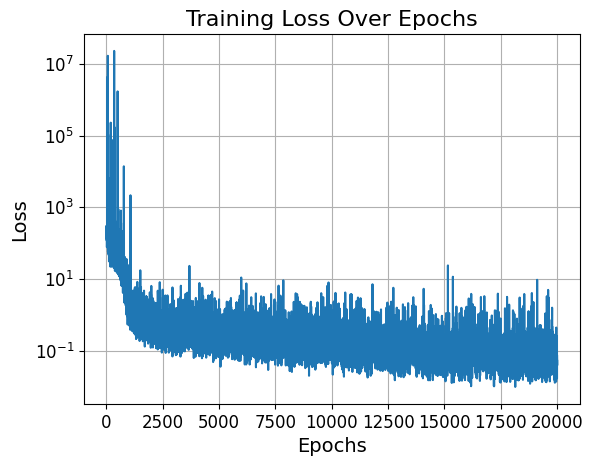

In [28]:
# En caso de entrenamiento se puede generar histogramas de perdida
# en caso contrario, no se generan histogramas.
plt.semilogy(range(len(model.loss_history)), model.loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid()

file_path = os.path.join(model.log_path, "loss_history.pdf")
plt.savefig(file_path, bbox_inches="tight")
plt.show()

plt.close(
    "all",
)

In [29]:
# Predictions
u_pred_star, f_pred_star = complex_wave_operator(model, X_star[:, 0:1], X_star[:, 1:2])

u_pred = u_pred_star.cpu().detach().numpy()
f_pred = f_pred_star.cpu().detach().numpy()
u_star = u_star.cpu().detach().numpy()
f_star = f_star.cpu().detach().numpy()
X = X_star.cpu().detach().numpy()

# Relative L2 error
error_u = (
    np.linalg.norm(u_pred - u_star) / np.linalg.norm(u_star) * 100
    if np.linalg.norm(u_star)
    else float("inf")
)
error_f = np.linalg.norm(f_pred - f_star)
logger.print("Relative L2 error_u: {:.2e}".format(error_u))
logger.print("Relative L2 error_f: {:.2e}".format(error_f))

INFO:src.utils.logger:Relative L2 error_u: 1.10e+02
INFO:src.utils.logger:Relative L2 error_f: 4.08e+02


/var/folders/bx/c3g0kthn3fqb7mgzj5q63zww0000gn/T/ipykernel_16922/3895102210.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  f_star.astype(np.float16),
/var/folders/bx/c3g0kthn3fqb7mgzj5q63zww0000gn/T/ipykernel_16922/3895102210.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  f_pred.astype(np.float16),
/Users/chubbs/Documents/UN/QCPINN/qpinns_env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/chubbs/Documents/UN/QCPINN/qpinns_env/lib/python3.9/site-packages/matplotlib/contour.py:1535: ComplexWarning: Casting complex values to real discards the imaginary part
  x = np.asarray(x, dtype=np.float64)
/Users/chubbs/Documents/UN/QCPINN/qpinns_env/lib/python3.9/site-packages/matplotlib/contour.py:1536: ComplexWarning: Casting complex values to real discards the imaginary part
  y = np.asarray(y, dtype=np.float64

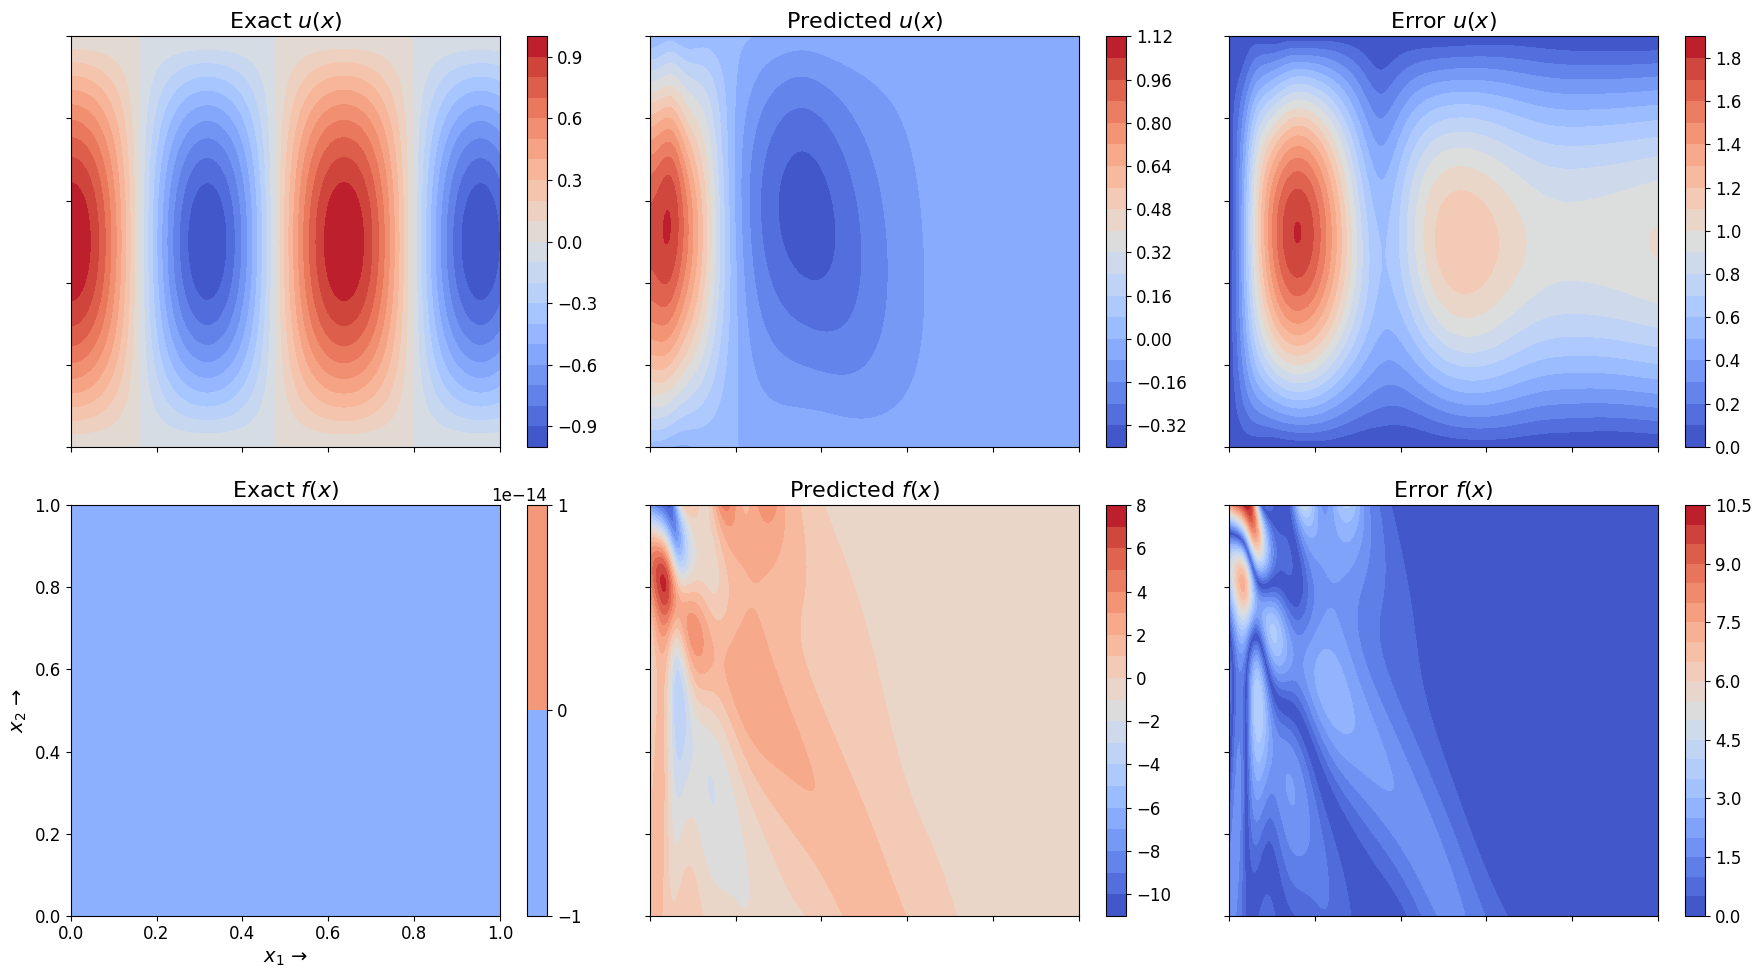

In [30]:
# Plot predictions
plt_prediction(
    logger,
    X,
    u_star,
    u_pred,
    f_star.astype(np.float16),
    f_pred.astype(np.float16),
)